In [444]:
# Project Title

In [445]:
# 🎬 Movie Rating Prediction with Python

## CODSOFT Data Science Internship - Task 2

### Project Objective

# The objective of this project is to analyze historical Indian movie data and develop a machine learning regression model that predicts the rating of a movie based on available features such as genre, director, actors,year, duration, and votes.

### Problem Type

# Regression

### Target Variable

# Rating

In [446]:
#_1_Import Libraries

In [447]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [448]:
#_2_Load the Dataset

In [449]:
# Load the IMDb India Movies dataset

import pandas as pd

data = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [450]:
#_3_Check Whether It Loaded Correctly

In [451]:
# Display the first five rows

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [452]:
#_4_Basic Dataset Information

In [453]:
# Check the shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 15509
Number of columns: 10


In [454]:
# Display column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [455]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [456]:
# Statistical summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,15509,13838,Anjaam,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,14981,102,(2019),410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,7240,182,120 min,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,13632,485,Drama,2780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,7919.0,NaN,NaN,NaN,5.841621,1.381777,1.1,4.9,6.0,6.8,10.0
Votes,7920,2034,8,227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Director,14984,5938,Jayant Desai,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor 1,13892,4718,Ashok Kumar,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor 2,13125,4891,Rekha,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor 3,12365,4820,Pran,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [457]:
#_5_Check Missing Values

In [458]:
# Check missing values

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

Duration    8269
Rating      7590
Votes       7589
Actor 3     3144
Actor 2     2384
Genre       1877
Actor 1     1617
Year         528
Director     525
dtype: int64

In [459]:
#_6_Check Duplicates

In [460]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 6


In [461]:
#_7_Data Cleaning


In [462]:
# Create a working copy of the dataset

movies = df.copy()

print("Working copy created successfully!")
print("Shape:", movies.shape)

Working copy created successfully!
Shape: (15509, 10)


In [463]:
# Check column names

print("Columns in the dataset:")
print(movies.columns.tolist())

Columns in the dataset:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [464]:

# Check missing values

missing_values = movies.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [465]:
#: Check data types

print(movies.dtypes)

Name         object
Year         object
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object


In [466]:
# Remove extra spaces from column names

data.columns = data.columns.str.strip()

print(data.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [467]:
# Check Rating values

print(data["Rating"].head(10))
print("\nData type:", data["Rating"].dtype)

0    NaN
1    7.0
2    NaN
3    4.4
4    NaN
5    4.7
6    7.4
7    NaN
8    5.6
9    4.0
Name: Rating, dtype: float64

Data type: float64


In [468]:
# Count missing ratings

print("Missing Rating values:", data["Rating"].isnull().sum())

Missing Rating values: 7590


In [469]:
# Statistical summary

movies.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,15509,13838,Anjaam,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,14981,102,(2019),410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,7240,182,120 min,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,13632,485,Drama,2780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,7919.0,NaN,NaN,NaN,5.841621,1.381777,1.1,4.9,6.0,6.8,10.0
Votes,7920,2034,8,227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Director,14984,5938,Jayant Desai,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor 1,13892,4718,Ashok Kumar,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor 2,13125,4891,Rekha,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actor 3,12365,4820,Pran,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [470]:
#_7_Remove Rows Without Rating

In [471]:
# Remove rows where Rating is missing

data = data.dropna(subset=["Rating"])

print("Dataset shape after removing missing ratings:", data.shape)

Dataset shape after removing missing ratings: (7919, 10)


In [472]:
# Convert Rating to numeric

data["Rating"] = pd.to_numeric(data["Rating"], errors="coerce")

# Remove any rows that could not be converted
data = data.dropna(subset=["Rating"])

print("Rating data type:", data["Rating"].dtype)

Rating data type: float64


In [473]:
#_8_Clean Year

In [474]:
# Clean Year column

data["Year"] = (
    data["Year"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
)

data["Year"] = pd.to_numeric(data["Year"], errors="coerce")

print(data["Year"].head())

1    2019
3    2019
5    1997
6    2005
8    2012
Name: Year, dtype: int64


In [475]:
print("Missing Year values:", data["Year"].isnull().sum())

Missing Year values: 0


In [476]:
#_9_Clean Duration

In [477]:
# Clean Duration column

data["Duration"] = (
    data["Duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
)

data["Duration"] = pd.to_numeric(data["Duration"], errors="coerce")

print(data["Duration"].head())

1    109.0
3    110.0
5    147.0
6    142.0
8     82.0
Name: Duration, dtype: float64


In [478]:
#_10_Clean Votes

In [479]:
# Clean Votes column

data["Votes"] = (
    data["Votes"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

data["Votes"] = pd.to_numeric(data["Votes"], errors="coerce")

print(data["Votes"].head())

1       8
3      35
5     827
6    1086
8     326
Name: Votes, dtype: int64


In [480]:
#_11_Handle Missing Numerical Values

In [481]:
# Check missing values in important numerical columns

print(data[["Year", "Duration", "Votes", "Rating"]].isnull().sum())

Year           0
Duration    2068
Votes          0
Rating         0
dtype: int64


In [482]:
# Fill missing numerical values with median

for column in ["Year", "Duration", "Votes"]:
    data[column] = data[column].fillna(data[column].median())

print("Missing numerical values handled.")

Missing numerical values handled.


In [483]:
#_12_Handle Missing Categorical Values

In [484]:
# Categorical columns

categorical_columns = [
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

# Fill missing categorical values

for column in categorical_columns:
    data[column] = data[column].fillna("Unknown")

print("Missing categorical values handled.")

Missing categorical values handled.


In [485]:
#_13_Remove Duplicate Movies

In [486]:
# Remove duplicate rows

before = len(data)

data = data.drop_duplicates()

after = len(data)

print("Duplicates removed:", before - after)
print("Current dataset shape:", data.shape)

Duplicates removed: 0
Current dataset shape: (7919, 10)


In [487]:
#_14_Final Missing Value Check

In [488]:
# Final missing value check

missing = data.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [489]:
#_15_Final Dataset Check

In [490]:
# Display cleaned dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7919 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7919 non-null   object 
 1   Year      7919 non-null   int64  
 2   Duration  7919 non-null   float64
 3   Genre     7919 non-null   object 
 4   Rating    7919 non-null   float64
 5   Votes     7919 non-null   int64  
 6   Director  7919 non-null   object 
 7   Actor 1   7919 non-null   object 
 8   Actor 2   7919 non-null   object 
 9   Actor 3   7919 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 680.5+ KB


In [491]:
# Display first five cleaned records

data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [492]:
#_16_Statistical summary

data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,7919.0,1993.321758,20.463770,1917.0,1979.5,1997.0,2011.0,2021.0
Duration,7919.0,132.739866,22.838302,21.0,124.0,134.0,143.0,321.0
Rating,7919.0,5.841621,1.381777,1.1,4.9,6.0,6.8,10.0
Votes,7919.0,1938.520394,11602.415952,5.0,16.0,55.0,404.0,591417.0


In [493]:
#_17_Distribution of Movie Ratings

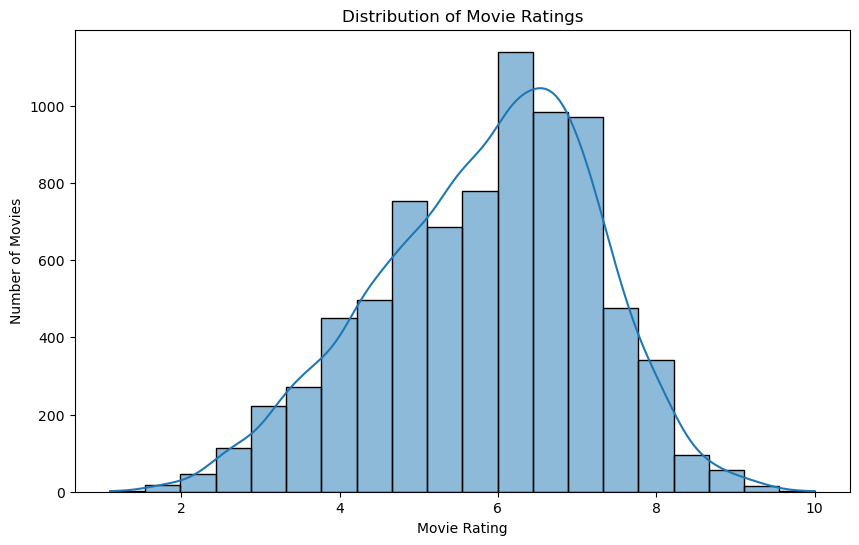

In [494]:
# Distribution of Movie Ratings

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="Rating",
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Movie Rating")
plt.ylabel("Number of Movies")

plt.show()

In [495]:
# Basic statistics of movie ratings

print("Minimum Rating:", data["Rating"].min())
print("Maximum Rating:", data["Rating"].max())
print("Average Rating:", round(data["Rating"].mean(), 2))
print("Median Rating:", data["Rating"].median())

Minimum Rating: 1.1
Maximum Rating: 10.0
Average Rating: 5.84
Median Rating: 6.0


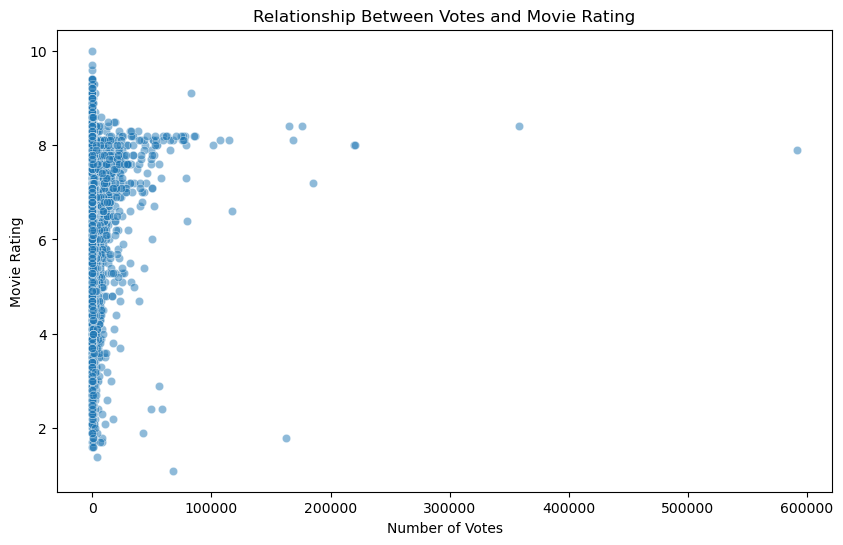

In [496]:
# Votes vs Rating

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Votes",
    y="Rating",
    alpha=0.5
)

plt.title("Relationship Between Votes and Movie Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Movie Rating")

plt.show()

In [497]:
# Correlation Analysis

correlation = data["Votes"].corr(data["Rating"])

print(
    "Correlation between Votes and Rating:",
    round(correlation, 3)
)

Correlation between Votes and Rating: 0.127


In [498]:
# Rating by Genre

# First check the genre data


print(data["Genre"].head(10))

1                         Drama
3               Comedy, Romance
5        Comedy, Drama, Musical
6           Drama, Romance, War
8     Horror, Mystery, Thriller
9       Action, Crime, Thriller
10                        Drama
11                       Horror
12    Horror, Romance, Thriller
13       Comedy, Drama, Romance
Name: Genre, dtype: object


In [499]:
# Average rating by genre

genre_rating = (
    data.groupby("Genre")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

genre_rating.head(15)

Genre
History, Romance                   9.40
Documentary, Family, History       9.30
Documentary, Music                 8.90
Documentary, Biography, Music      8.80
Documentary, Sport                 8.60
Animation, Comedy, Family          8.30
Biography, Family                  8.30
Documentary, Thriller              8.25
Documentary, Biography, Family     8.25
Documentary, Biography, Sport      8.20
Documentary, Drama, Sport          8.10
Drama, Musical, Sport              8.10
Documentary, Biography, Musical    8.05
Crime, Drama, History              8.05
Comedy, Musical, Drama             8.00
Name: Rating, dtype: float64

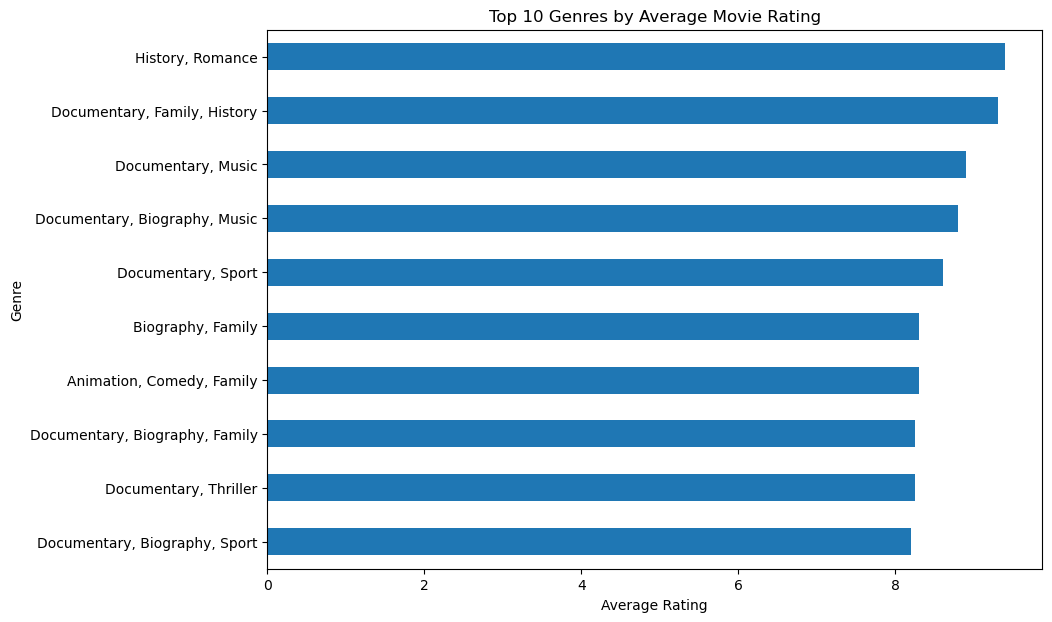

In [500]:
# Visualize

plt.figure(figsize=(10, 7))

genre_rating.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Genres by Average Movie Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

In [501]:
# Rating by Year

yearly_rating = (
    data.groupby("Year")["Rating"]
    .mean()
    .sort_index()
)

yearly_rating.head()

Year
1917    6.70
1931    5.90
1932    5.10
1933    5.74
1934    6.04
Name: Rating, dtype: float64

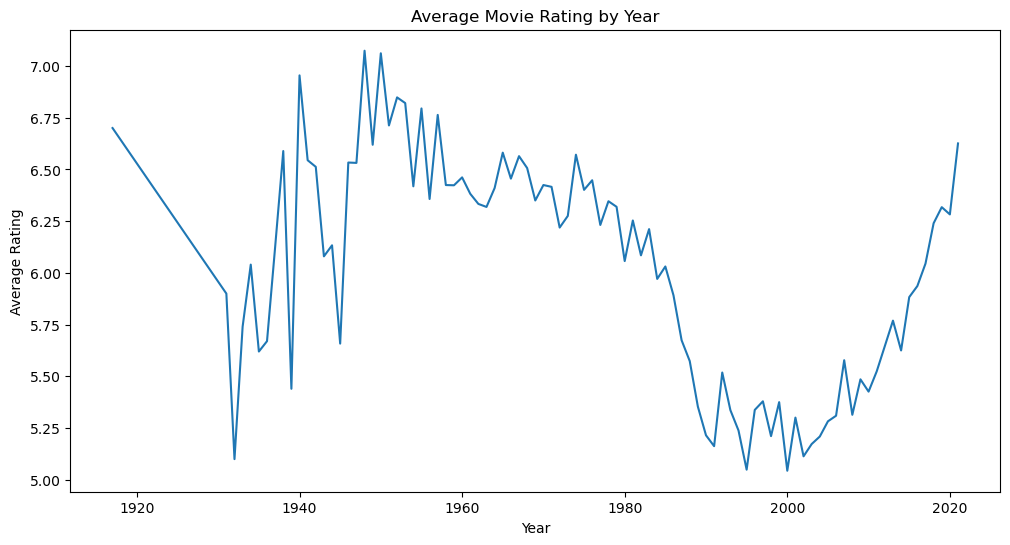

In [502]:
# plot

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_rating.index,
    yearly_rating.values
)

plt.title("Average Movie Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")

plt.show()

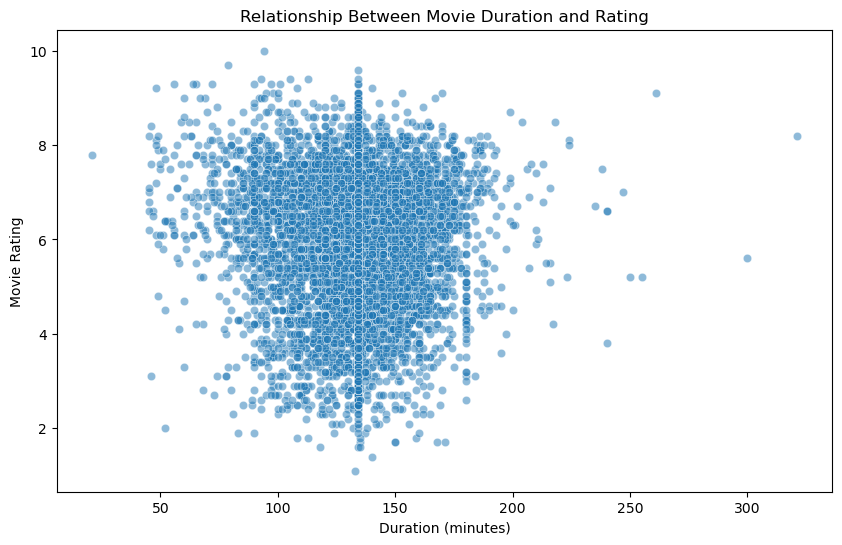

In [503]:
# Duration vs Rating

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="Duration",
    y="Rating",
    alpha=0.5
)

plt.title("Relationship Between Movie Duration and Rating")
plt.xlabel("Duration (minutes)")
plt.ylabel("Movie Rating")

plt.show()

In [504]:
# Calculate correlation


duration_correlation = data["Duration"].corr(data["Rating"])

print(
    "Correlation between Duration and Rating:",
    round(duration_correlation, 3)
)

Correlation between Duration and Rating: -0.03


In [505]:
# Directors and Average Ratings


director_stats = (
    data.groupby("Director")
    .agg(
        Movie_Count=("Rating", "count"),
        Average_Rating=("Rating", "mean")
    )
)

director_stats = director_stats[
    director_stats["Movie_Count"] >= 5
]

director_stats = director_stats.sort_values(
    "Average_Rating",
    ascending=False
)

director_stats.head(10)




,Movie_Count,Average_Rating
Director,,
Anand Patwardhan,8,8.287500
Rajkumar Hirani,5,8.060000
Gulzar,19,7.521053
Shoojit Sircar,7,7.500000
Guru Dutt,8,7.487500
Kidar Nath Sharma,9,7.466667
Neeraj Pandey,5,7.460000
Anurag Kashyap,14,7.385714
Dibakar Banerjee,6,7.383333


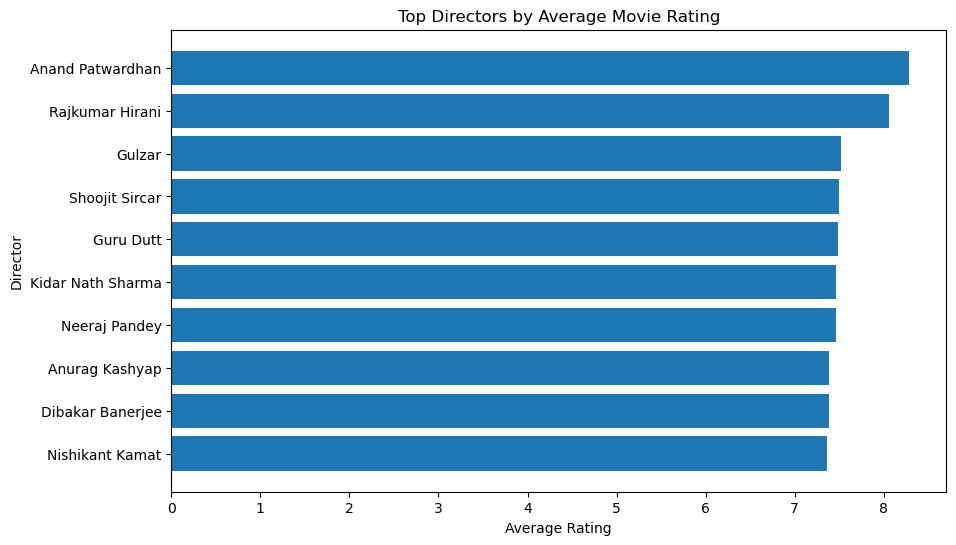

In [506]:
# # Plot


top_directors = director_stats.head(10).sort_values(
    "Average_Rating"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_directors.index,
    top_directors["Average_Rating"]
)

plt.title("Top Directors by Average Movie Rating")
plt.xlabel("Average Rating")
plt.ylabel("Director")

plt.show()

In [507]:
#_18_Feature Engineering

In [508]:
# First, inspect the cleaned data

# Check current columns

print(data.columns.tolist())

# Check the first few rows

data.head()

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [509]:
# Create a new feature-engineering dataset

# Create a feature engineering copy

model_data = data.copy()

print("Model dataset created.")
print("Shape:", model_data.shape)



Model dataset created.
Shape: (7919, 10)


In [510]:
# Create Movie Age


REFERENCE_YEAR = 2024

model_data["MovieAge"] = REFERENCE_YEAR - model_data["Year"]

print(model_data[["Year", "MovieAge"]].head())

   Year  MovieAge
1  2019         5
3  2019         5
5  1997        27
6  2005        19
8  2012        12


In [511]:
# Create Decade


model_data["Decade"] = (model_data["Year"] // 10) * 10

print(model_data[["Year", "Decade"]].head())

   Year  Decade
1  2019    2010
3  2019    2010
5  1997    1990
6  2005    2000
8  2012    2010


In [512]:
# Create a Log Votes Feature

# Log-transform Votes

model_data["LogVotes"] = np.log1p(model_data["Votes"])

print(model_data[["Votes", "LogVotes"]].head())

   Votes  LogVotes
1      8  2.197225
3     35  3.583519
5    827  6.719013
6   1086  6.991177
8    326  5.789960


In [513]:
# Create Genre Count

# Number of genres

model_data["GenreCount"] = (
    model_data["Genre"]
    .astype(str)
    .str.split(",")
    .apply(len)
)

print(model_data[["Genre", "GenreCount"]].head(10))

                        Genre  GenreCount
1                       Drama           1
3             Comedy, Romance           2
5      Comedy, Drama, Musical           3
6         Drama, Romance, War           3
8   Horror, Mystery, Thriller           3
9     Action, Crime, Thriller           3
10                      Drama           1
11                     Horror           1
12  Horror, Romance, Thriller           3
13     Comedy, Drama, Romance           3


In [514]:
# Create Actor Count

# Count available actors

actor_columns = ["Actor 1", "Actor 2", "Actor 3"]

model_data["ActorCount"] = (
    model_data[actor_columns]
    .replace("Unknown", np.nan)
    .notna()
    .sum(axis=1)
)

print(model_data[actor_columns + ["ActorCount"]].head(10))

            Actor 1                 Actor 2          Actor 3  ActorCount
1      Rasika Dugal          Vivek Ghamande    Arvind Jangid           3
3           Prateik              Ishita Raj  Siddhant Kapoor           3
5        Bobby Deol  Aishwarya Rai Bachchan    Shammi Kapoor           3
6   Jimmy Sheirgill          Minissha Lamba   Yashpal Sharma           3
8         Yash Dave          Muntazir Ahmad     Kiran Bhatia           3
9         Augustine            Fathima Babu             Byon           3
10   Rati Agnihotri          Gulshan Grover    Atul Kulkarni           3
11     Pankaj Berry            Anubhav Dhir     Hritu Dudani           3
12    Jackie Shroff           Madhuri Dixit    Javed Jaffrey           3
13             Jeet           Koyel Mallick      Sujoy Ghosh           3


In [515]:
# Check the new features

# Display engineered features

engineered_features = [
    "Year",
    "Duration",
    "Votes",
    "MovieAge",
    "Decade",
    "LogVotes",
    "GenreCount",
    "ActorCount",
    "Rating"
]

model_data[engineered_features].head()

,Year,Duration,Votes,MovieAge,Decade,LogVotes,GenreCount,ActorCount,Rating
1,2019,109.0,8,5,2010,2.197225,1,3,7.0
3,2019,110.0,35,5,2010,3.583519,2,3,4.4
5,1997,147.0,827,27,1990,6.719013,3,3,4.7
6,2005,142.0,1086,19,2000,6.991177,3,3,7.4
8,2012,82.0,326,12,2010,5.789960,3,3,5.6


In [516]:
# Check the new feature statistics


# Statistical summary of engineered numerical features

model_data[
    [
        "Year",
        "Duration",
        "Votes",
        "MovieAge",
        "Decade",
        "LogVotes",
        "GenreCount",
        "ActorCount",
        "Rating"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,7919.0,1993.321758,20.463770,1917.000000,1979.500000,1997.000000,2011.000000,2021.000000
Duration,7919.0,132.739866,22.838302,21.000000,124.000000,134.000000,143.000000,321.000000
Votes,7919.0,1938.520394,11602.415952,5.000000,16.000000,55.000000,404.000000,591417.000000
MovieAge,7919.0,30.678242,20.463770,3.000000,13.000000,27.000000,44.500000,107.000000
Decade,7919.0,1988.743528,20.482923,1910.000000,1975.000000,1990.000000,2010.000000,2020.000000
LogVotes,7919.0,4.623697,2.205619,1.791759,2.833213,4.025352,6.003887,13.290278
GenreCount,7919.0,1.999874,0.842856,1.000000,1.000000,2.000000,3.000000,3.000000
ActorCount,7919.0,2.922086,0.430717,0.000000,3.000000,3.000000,3.000000,3.000000
Rating,7919.0,5.841621,1.381777,1.100000,4.900000,6.000000,6.800000,10.000000


In [517]:
#_18_Feature Selection

In [518]:
#  Define target variable

y = model_data["Rating"]

print("Target variable: Rating")
print("Number of target values:", len(y))

Target variable: Rating
Number of target values: 7919


In [519]:
# Select useful features

# Select input features

feature_columns = [
    "Year",
    "Duration",
    "Votes",
    "MovieAge",
    "Decade",
    "LogVotes",
    "GenreCount",
    "ActorCount",
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

X = model_data[feature_columns].copy()

print("Features selected successfully!")
print("Number of features:", X.shape[1])
print("Number of records:", X.shape[0])

Features selected successfully!
Number of features: 13
Number of records: 7919


In [520]:
# Check X

# Display input features

X.head()

,Year,Duration,Votes,MovieAge,Decade,LogVotes,GenreCount,ActorCount,Genre,Director,Actor 1,Actor 2,Actor 3
1,2019,109.0,8,5,2010,2.197225,1,3,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,2019,110.0,35,5,2010,3.583519,2,3,"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,1997,147.0,827,27,1990,6.719013,3,3,"Comedy, Drama, Musical",Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,2005,142.0,1086,19,2000,6.991177,3,3,"Drama, Romance, War",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,2012,82.0,326,12,2010,5.789960,3,3,"Horror, Mystery, Thriller",Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [521]:
# Check y

# Display target variable

y.head()

1    7.0
3    4.4
5    4.7
6    7.4
8    5.6
Name: Rating, dtype: float64

In [522]:
# Check feature data types

# Check data types of selected features

print(X.dtypes)

Year            int64
Duration      float64
Votes           int64
MovieAge        int64
Decade          int64
LogVotes      float64
GenreCount      int64
ActorCount      int64
Genre          object
Director       object
Actor 1        object
Actor 2        object
Actor 3        object
dtype: object


In [523]:
# Separate numerical and categorical features

numerical_features = [
    "Year",
    "Duration",
    "Votes",
    "MovieAge",
    "Decade",
    "LogVotes",
    "GenreCount",
    "ActorCount"
]

categorical_features = [
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Year', 'Duration', 'Votes', 'MovieAge', 'Decade', 'LogVotes', 'GenreCount', 'ActorCount']

Categorical features:
['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [524]:
# _19_Preprocessing

In [525]:
# Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Preprocessing tools imported successfully!")

Preprocessing tools imported successfully!


In [526]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

handle_unknown="ignore"

Preprocessing pipeline created successfully!


In [527]:
# Check the preprocessing object

# Display preprocessing configuration

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Year', 'Duration', 'Votes', 'MovieAge',
                                  'Decade', 'LogVotes', 'GenreCount',
                                  'ActorCount']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               min_frequency=2),
                                 ['Genre', 'Director', 'Actor 1', 'Actor 2',
                                  'Actor 3'])])


In [528]:
# Important: We don't fit it yet

preprocessor.fit_transform(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 102947 stored elements and shape (7919, 4076)>

In [529]:
#_20_Train/Test Split

In [530]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (6335, 13)
Testing features: (1584, 13)
Training target: (6335,)
Testing target: (1584,)


In [531]:
# Verify training and testing data

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6335, 13)
X_test shape: (1584, 13)

y_train shape: (6335,)
y_test shape: (1584,)


In [532]:
# Compare target statistics

print("Training Rating Statistics:")
print(y_train.describe())

print("\nTesting Rating Statistics:")
print(y_test.describe())

Training Rating Statistics:
count    6335.000000
mean        5.831018
std         1.386106
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64

Testing Rating Statistics:
count    1584.000000
mean        5.884028
std         1.363935
min         1.900000
25%         5.000000
50%         6.000000
75%         6.900000
max         9.300000
Name: Rating, dtype: float64


In [533]:
# View training data

X_train.head()

,Year,Duration,Votes,MovieAge,Decade,LogVotes,GenreCount,ActorCount,Genre,Director,Actor 1,Actor 2,Actor 3
8157,2019,74.0,10,5,2010,2.397895,2,3,"Comedy, Drama",Ronit Jadhav,Ronit Jadhav,Rohit D'Souza,Darshil Gandhi
8455,1981,134.0,16,43,1980,2.833213,1,3,Drama,Shibu Mitra,Shashi Kapoor,Pran,Amjad Khan
14490,2017,136.0,17774,7,2010,9.785548,2,3,"Drama, War",Kabir Khan,Salman Khan,Sohail Khan,Om Puri
2697,2003,117.0,17,21,2000,2.890372,1,3,Action,Gautam Verma,Rajat Bedi,Mithun Chakraborty,Dinesh Hingoo
15470,1988,120.0,33,36,1980,3.526361,3,3,"Documentary, Biography, Musical",Sandip Ray,Kishore Kumar,Amitabh Bachchan,Asha Bhosle


In [534]:
# View training target values

y_train.head()

8157     8.8
8455     6.0
14490    3.8
2697     5.8
15470    8.2
Name: Rating, dtype: float64

In [535]:
#_21_Regression Models

In [536]:
# Import regression models

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

print("Regression models imported successfully!")

Regression models imported successfully!


In [537]:
# Import Pipeline

from sklearn.pipeline import Pipeline

print("Pipeline imported successfully!")

Pipeline imported successfully!


In [538]:
# Define regression models

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting
- Extra Trees


In [539]:
# Create preprocessing + model pipelines

pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("All pipelines created successfully!")

All pipelines created successfully!


In [540]:
# Display pipelines

for name, pipeline in pipelines.items():
    print("\n", name)
    print(pipeline)


 Linear Regression
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Duration', 'Votes',
                                                   'MovieAge', 'Decade',
                                                   'LogVotes', 'GenreCount',
                                                   'ActorCount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=2),
                                                  ['Genre', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3'])])),
                ('model', LinearRegression())])

 Ridge Regression
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(

In [541]:
# Train all regression models

trained_models = {}

for name, pipeline in pipelines.items():

    print("Training:", name)

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

print("\nAll models trained successfully!")

Training: Linear Regression
Training: Ridge Regression
Training: Random Forest
Training: Gradient Boosting
Training: Extra Trees

All models trained successfully!


In [542]:
#_22_Model Evaluation

In [543]:
# Import regression evaluation metrics

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [544]:
# Evaluate all models

results = []

for name, pipeline in trained_models.items():

    # Make predictions on test data
    prediction = pipeline.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, prediction)

    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )

    r2 = r2_score(y_test, prediction)

    # Store results
    results.append([
        name,
        mae,
        rmse,
        r2
    ])

print("Model evaluation completed!")

Model evaluation completed!


In [545]:
# Create model comparison table

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.129859,1.460925,-0.148002
1,Ridge Regression,0.940389,1.209038,0.213740
2,Random Forest,0.809665,1.086717,0.364786
3,Gradient Boosting,0.857266,1.114271,0.332166
4,Extra Trees,0.813063,1.095629,0.354325


In [546]:
# Sort models by R2 Score

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.809665,1.086717,0.364786
1,Extra Trees,0.813063,1.095629,0.354325
2,Gradient Boosting,0.857266,1.114271,0.332166
3,Ridge Regression,0.940389,1.209038,0.213740
4,Linear Regression,1.129859,1.460925,-0.148002


In [547]:
# Identify the best model

best_model_name = results_df.loc[0, "Model"]

print("Best Model:", best_model_name)
print("\nBest Model Performance:")
print(results_df.iloc[0])

Best Model: Random Forest

Best Model Performance:
Model       Random Forest
MAE              0.809665
RMSE             1.086717
R2 Score         0.364786
Name: 0, dtype: object


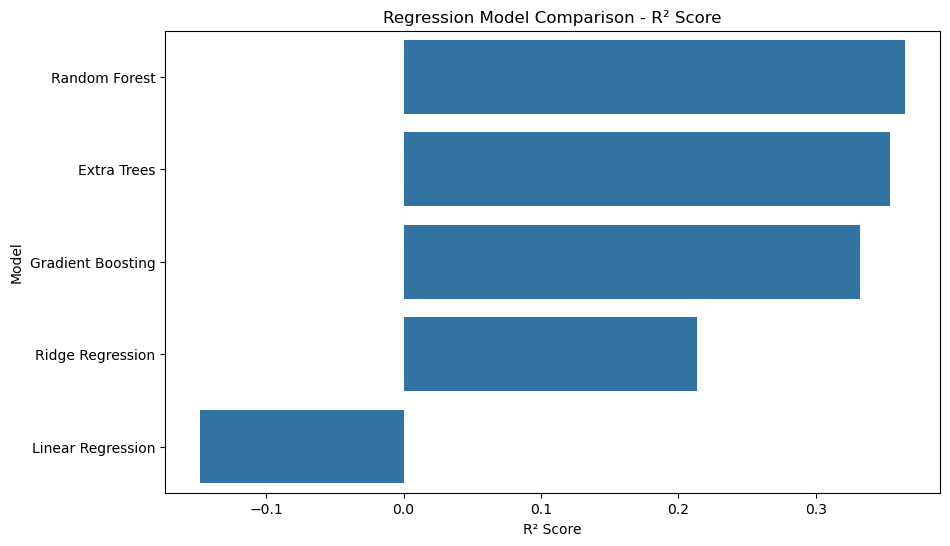

In [548]:
# Compare R2 Scores

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("Regression Model Comparison - R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

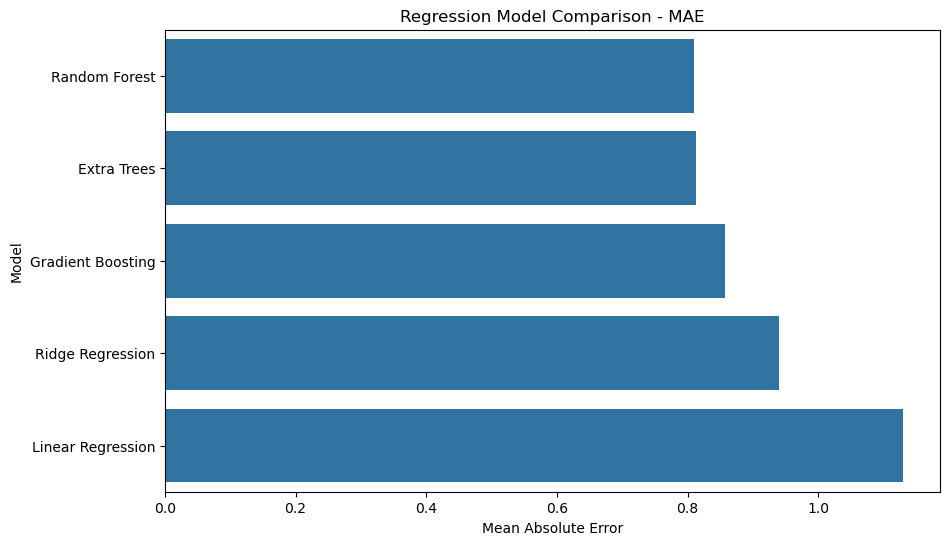

In [549]:
# Compare MAE

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("Regression Model Comparison - MAE")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

plt.show()

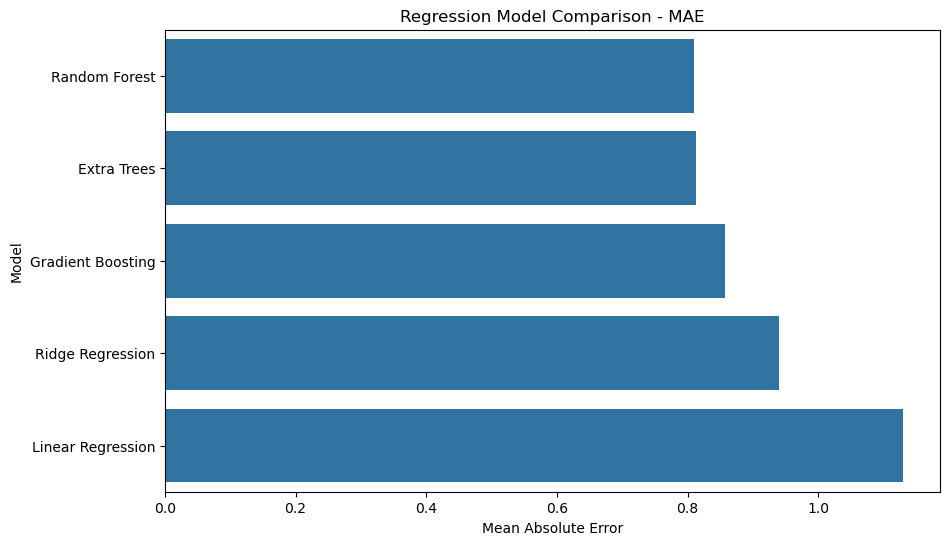

In [550]:
# Compare MAE

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("Regression Model Comparison - MAE")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")

plt.show()

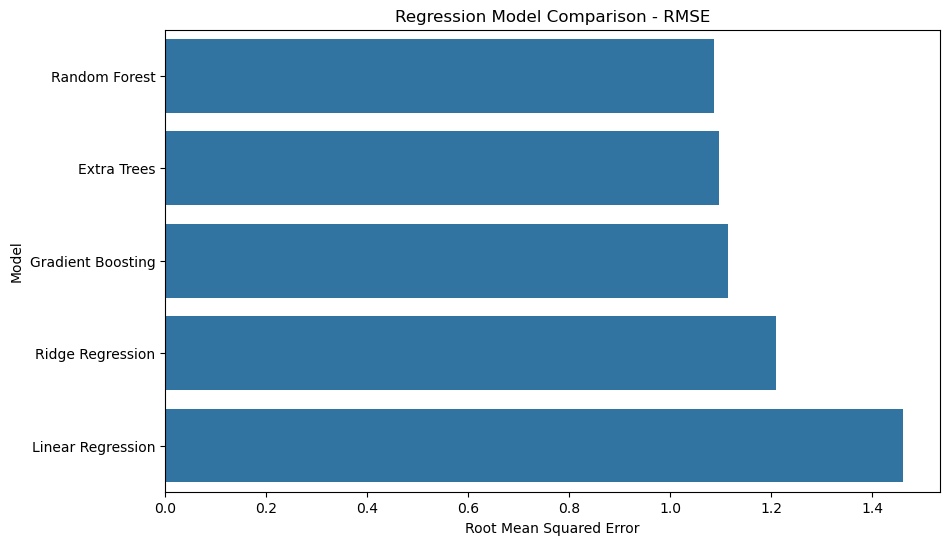

In [551]:
# Compare RMSE

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Regression Model Comparison - RMSE")
plt.xlabel("Root Mean Squared Error")
plt.ylabel("Model")

plt.show()

In [552]:
#_23_Hyperparameter Tuning

In [553]:
# Check the best model

print("Best model from Step 19:", best_model_name)

Best model from Step 19: Random Forest


In [554]:
# Import hyperparameter tuning tools

from sklearn.model_selection import RandomizedSearchCV

print("RandomizedSearchCV imported successfully!")

RandomizedSearchCV imported successfully!


In [555]:

# Fast Random Forest Hyperparameter Tuning

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=4,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest tuning...")

rf_search.fit(X_train, y_train)

print("Random Forest tuning completed!")

Starting Random Forest tuning...
Random Forest tuning completed!


In [556]:
# Display best parameters

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation R2:")
print(round(rf_search.best_score_, 4))

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 20}

Best Cross-Validation R2:
0.3244


In [557]:
# Tune Extra Trees

et_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

et_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

et_search = RandomizedSearchCV(
    estimator=et_pipeline,
    param_distributions=et_params,
    n_iter=10,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Starting Extra Trees tuning...")

et_search.fit(X_train, y_train)

print("Extra Trees tuning completed!")

Starting Extra Trees tuning...
Extra Trees tuning completed!


In [558]:
print("Best Parameters:")
print(et_search.best_params_)

print("\nBest Cross-Validation R2:")
print(round(et_search.best_score_, 4))

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_depth': 20}

Best Cross-Validation R2:
0.3172


In [559]:
# Tune Gradient Boosting

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_params = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=10,
    scoring="r2",
    cv=3,
    random_state=42,
    n_jobs=-1
)

print("Starting Gradient Boosting tuning...")

gb_search.fit(X_train, y_train)

print("Gradient Boosting tuning completed!")

Starting Gradient Boosting tuning...
Gradient Boosting tuning completed!


In [560]:
print("Best Parameters:")
print(gb_search.best_params_)

print("\nBest Cross-Validation R2:")
print(round(gb_search.best_score_, 4))

Best Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 10, 'model__max_depth': 3, 'model__learning_rate': 0.1}

Best Cross-Validation R2:
0.325


In [561]:
#_24_Final Model Evaluation

In [562]:
# Get the tuned model

if best_model_name == "Random Forest":
    tuned_model = rf_search.best_estimator_

elif best_model_name == "Extra Trees":
    tuned_model = et_search.best_estimator_

elif best_model_name == "Gradient Boosting":
    tuned_model = gb_search.best_estimator_

else:
    tuned_model = trained_models[best_model_name]

print("Final model:", best_model_name)

Final model: Random Forest


In [563]:
# Make predictions using the tuned model

final_prediction = tuned_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(final_prediction))

Predictions generated successfully!
Number of predictions: 1584


In [564]:
# SCalculate final model performance

final_mae = mean_absolute_error(y_test, final_prediction)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_prediction)
)

final_r2 = r2_score(y_test, final_prediction)

print("Final Model Performance")
print("-----------------------")
print("MAE  :", round(final_mae, 4))
print("RMSE :", round(final_rmse, 4))
print("R²   :", round(final_r2, 4))

Final Model Performance
-----------------------
MAE  : 0.8227
RMSE : 1.0922
R²   : 0.3584


In [565]:
# Compare original and tuned model

original_result = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score"],
    "Before Tuning": [
        original_result["MAE"],
        original_result["RMSE"],
        original_result["R2 Score"]
    ],
    "After Tuning": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,MAE,0.809665,0.822730
1,RMSE,1.086717,1.092161
2,R2 Score,0.364786,0.358406


In [566]:
#_25_Actual vs Predicted Ratings

In [567]:
# Create Actual vs Predicted DataFrame

prediction_df = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": final_prediction
})

prediction_df.head(10)

,Actual Rating,Predicted Rating
0,3.3,4.354082
1,5.3,4.917322
2,5.7,5.434320
3,7.2,5.364147
4,3.5,5.321344
5,7.2,6.037587
6,3.8,5.129092
7,6.9,6.912739
8,5.2,5.546057
9,7.4,6.109214


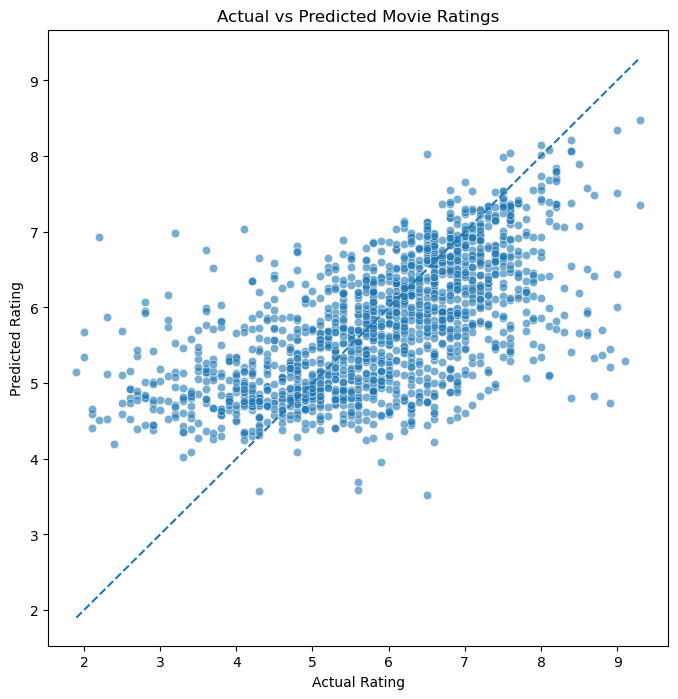

In [568]:
# Actual vs Predicted Ratings

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=prediction_df,
    x="Actual Rating",
    y="Predicted Rating",
    alpha=0.6
)

# Perfect prediction line
min_rating = min(
    prediction_df["Actual Rating"].min(),
    prediction_df["Predicted Rating"].min()
)

max_rating = max(
    prediction_df["Actual Rating"].max(),
    prediction_df["Predicted Rating"].max()
)

plt.plot(
    [min_rating, max_rating],
    [min_rating, max_rating],
    linestyle="--"
)

plt.title("Actual vs Predicted Movie Ratings")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.show()

In [569]:
# Calculate prediction error

prediction_df["Error"] = (
    prediction_df["Actual Rating"]
    - prediction_df["Predicted Rating"]
)

prediction_df.head(10)

,Actual Rating,Predicted Rating,Error
0,3.3,4.354082,-1.054082
1,5.3,4.917322,0.382678
2,5.7,5.434320,0.265680
3,7.2,5.364147,1.835853
4,3.5,5.321344,-1.821344
5,7.2,6.037587,1.162413
6,3.8,5.129092,-1.329092
7,6.9,6.912739,-0.012739
8,5.2,5.546057,-0.346057
9,7.4,6.109214,1.290786


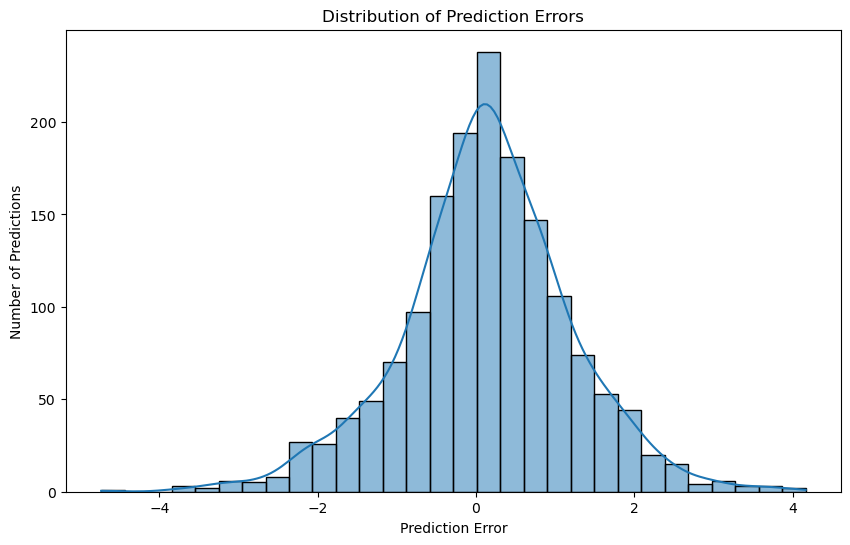

In [570]:
# Distribution of prediction errors

plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_df["Error"],
    bins=30,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Number of Predictions")

plt.show()

In [571]:
# Find predictions with the largest errors

prediction_df["Absolute Error"] = (
    prediction_df["Error"].abs()
)

largest_errors = prediction_df.sort_values(
    by="Absolute Error",
    ascending=False
)

largest_errors.head(10)

,Actual Rating,Predicted Rating,Error,Absolute Error
1276,2.2,6.935391,-4.735391,4.735391
278,8.9,4.736718,4.163282,4.163282
1485,8.7,4.832850,3.867150,3.867150
523,9.1,5.296441,3.803559,3.803559
798,3.2,6.987583,-3.787583,3.787583
1512,8.9,5.209626,3.690374,3.690374
806,2.0,5.673372,-3.673372,3.673372
1468,8.4,4.799438,3.600562,3.600562
1231,2.3,5.875815,-3.575815,3.575815
437,8.9,5.455601,3.444399,3.444399


In [572]:
#_26_Feature Importance

In [573]:
 # Check final model

final_estimator = tuned_model.named_steps["model"]

print("Final model:")
print(final_estimator)

print("\nModel type:")
print(type(final_estimator))

Final model:
RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)

Model type:
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [574]:
tuned_model.named_steps["model"]

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)

In [575]:
# Check feature importance support

if hasattr(final_estimator, "feature_importances_"):
    print("This model supports feature importance.")
else:
    print("This model does not provide feature_importances_.")

This model supports feature importance.


In [576]:
# Get feature names after preprocessing

fitted_preprocessor = tuned_model.named_steps["preprocessor"]

feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 3460

First 20 processed features:
['num__Year' 'num__Duration' 'num__Votes' 'num__MovieAge' 'num__Decade'
 'num__LogVotes' 'num__GenreCount' 'num__ActorCount' 'cat__Genre_Action'
 'cat__Genre_Action, Adventure' 'cat__Genre_Action, Adventure, Comedy'
 'cat__Genre_Action, Adventure, Crime'
 'cat__Genre_Action, Adventure, Drama'
 'cat__Genre_Action, Adventure, Family'
 'cat__Genre_Action, Adventure, Fantasy'
 'cat__Genre_Action, Adventure, Musical'
 'cat__Genre_Action, Adventure, Romance'
 'cat__Genre_Action, Adventure, Sci-Fi'
 'cat__Genre_Action, Adventure, Thriller'
 'cat__Genre_Action, Biography, Crime']


In [577]:
# Get feature importance

importance = final_estimator.feature_importances_

print("Number of importance values:", len(importance))

Number of importance values: 3460


In [578]:
# Get feature importance

importance = final_estimator.feature_importances_

print("Number of importance values:", len(importance))

Number of importance values: 3460


In [579]:
# Extract feature names and importance values

model = rf_search.best_estimator_

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

print("Number of features:", len(feature_names))
print("Number of importance values:", len(importances))

feature_importance.head()

Number of features: 3460
Number of importance values: 3460


,Feature,Importance
0,num__Year,0.112013
1,num__Duration,0.112893
2,num__Votes,0.140605
3,num__MovieAge,0.132077
4,num__Decade,0.007555


In [580]:
# Sort feature importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,num__LogVotes,0.144630
1,num__Votes,0.140605
2,num__MovieAge,0.132077
3,num__Duration,0.112893
4,num__Year,0.112013
5,cat__Genre_Drama,0.028466
6,cat__Genre_Documentary,0.021927
7,num__GenreCount,0.018530
8,cat__Actor 2_infrequent_sklearn,0.017660
9,cat__Director_infrequent_sklearn,0.016636


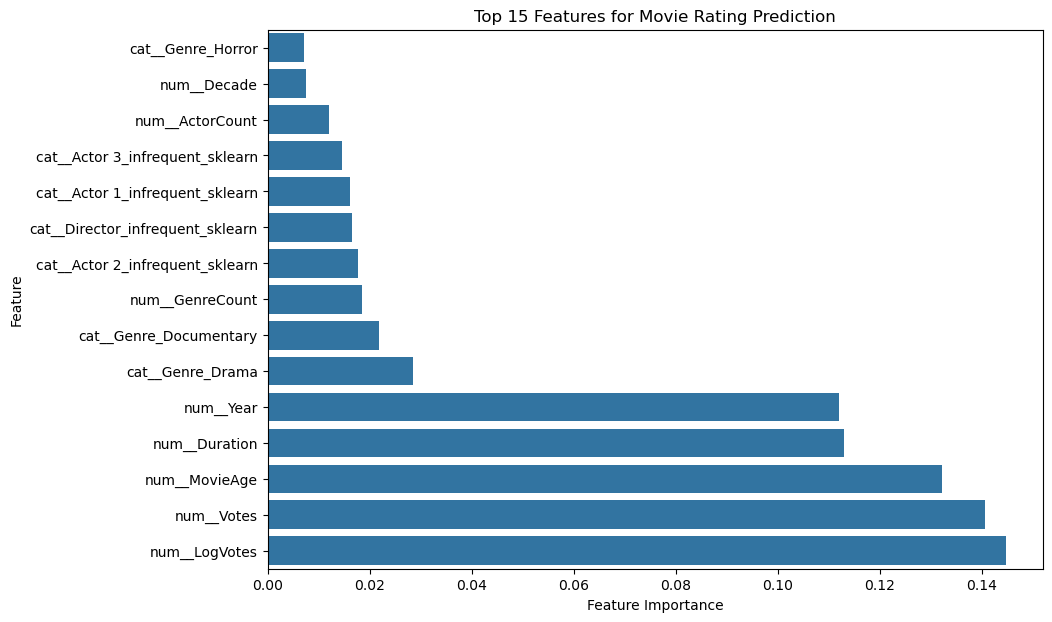

In [581]:
# Plot top 15 important features

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features for Movie Rating Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [582]:
# Top 5 features

top_5_features = feature_importance.head(5)

top_5_features

,Feature,Importance
0,num__LogVotes,0.144630
1,num__Votes,0.140605
2,num__MovieAge,0.132077
3,num__Duration,0.112893
4,num__Year,0.112013


In [583]:
# Calculate relative importance percentage

feature_importance["Importance_Percentage"] = (
    feature_importance["Importance"]
    / feature_importance["Importance"].sum()
) * 100

feature_importance.head(10)

,Feature,Importance,Importance_Percentage
0,num__LogVotes,0.144630,14.463003
1,num__Votes,0.140605,14.060456
2,num__MovieAge,0.132077,13.207664
3,num__Duration,0.112893,11.289331
4,num__Year,0.112013,11.201341
5,cat__Genre_Drama,0.028466,2.846598
6,cat__Genre_Documentary,0.021927,2.192662
7,num__GenreCount,0.018530,1.852979
8,cat__Actor 2_infrequent_sklearn,0.017660,1.765992
9,cat__Director_infrequent_sklearn,0.016636,1.663612


In [584]:
#_27_Movie Rating Prediction Function

In [585]:
# Check required feature columns

print("Features required by the model:")
print(feature_columns)

Features required by the model:
['Year', 'Duration', 'Votes', 'MovieAge', 'Decade', 'LogVotes', 'GenreCount', 'ActorCount', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [586]:
# Create movie rating prediction function

def predict_movie_rating(
    year,
    duration,
    votes,
    genre,
    director,
    actor1,
    actor2,
    actor3,
    genre_count,
    actor_count
):
    
    # Calculate engineered features
    movie_age = 2026 - year
    decade = (year // 10) * 10
    log_votes = np.log1p(votes)
    
    # Create input DataFrame
    movie_data = pd.DataFrame({
        "Year": [year],
        "Duration": [duration],
        "Votes": [votes],
        "MovieAge": [movie_age],
        "Decade": [decade],
        "LogVotes": [log_votes],
        "GenreCount": [genre_count],
        "ActorCount": [actor_count],
        "Genre": [genre],
        "Director": [director],
        "Actor 1": [actor1],
        "Actor 2": [actor2],
        "Actor 3": [actor3]
    })
    
    # Predict rating
    predicted_rating = tuned_model.predict(movie_data)[0]
    
    return predicted_rating

In [587]:
# Test prediction function

predicted_rating = predict_movie_rating(
    year=2020,
    duration=120,
    votes=5000,
    genre="Drama",
    director="Test Director",
    actor1="Test Actor 1",
    actor2="Test Actor 2",
    actor3="Test Actor 3",
    genre_count=1,
    actor_count=3
)

print("Predicted Movie Rating:", round(predicted_rating, 2))

Predicted Movie Rating: 6.71


In [588]:
# Check rating range

print("Minimum training rating:", y_train.min())
print("Maximum training rating:", y_train.max())

Minimum training rating: 1.1
Maximum training rating: 10.0


In [589]:
# Improved movie rating prediction function

def predict_movie_rating(
    year,
    duration,
    votes,
    genre,
    director,
    actor1,
    actor2,
    actor3,
    genre_count,
    actor_count
):
    
    # Engineered features
    movie_age = 2026 - year
    decade = (year // 10) * 10
    log_votes = np.log1p(votes)
    
    # Input data
    movie_data = pd.DataFrame({
        "Year": [year],
        "Duration": [duration],
        "Votes": [votes],
        "MovieAge": [movie_age],
        "Decade": [decade],
        "LogVotes": [log_votes],
        "GenreCount": [genre_count],
        "ActorCount": [actor_count],
        "Genre": [genre],
        "Director": [director],
        "Actor 1": [actor1],
        "Actor 2": [actor2],
        "Actor 3": [actor3]
    })
    
    # Prediction
    predicted_rating = tuned_model.predict(movie_data)[0]
    
    # Keep prediction within observed training range
    predicted_rating = np.clip(
        predicted_rating,
        y_train.min(),
        y_train.max()
    )
    
    return predicted_rating

In [590]:
# Test improved prediction function

predicted_rating = predict_movie_rating(
    year=2020,
    duration=120,
    votes=5000,
    genre="Drama",
    director="Test Director",
    actor1="Test Actor 1",
    actor2="Test Actor 2",
    actor3="Test Actor 3",
    genre_count=1,
    actor_count=3
)

print(
    "Predicted Movie Rating:",
    round(predicted_rating, 2)
)

Predicted Movie Rating: 6.71


In [591]:
# Another prediction

rating = predict_movie_rating(
    year=2015,
    duration=140,
    votes=15000,
    genre="Action",
    director="Another Director",
    actor1="Actor A",
    actor2="Actor B",
    actor3="Actor C",
    genre_count=1,
    actor_count=3
)

print("Predicted Rating:", round(rating, 2))

Predicted Rating: 7.04


In [592]:
#_28_Residual Analysis

In [593]:
# Calculate residuals

residuals = y_test.values - final_prediction

print("Residual analysis completed!")
print("Number of residuals:", len(residuals))

Residual analysis completed!
Number of residuals: 1584


In [594]:
# SResidual statistics

residual_stats = pd.Series(residuals).describe()

residual_stats

count    1584.000000
mean        0.126063
std         1.085204
min        -4.735391
25%        -0.480669
50%         0.136342
75%         0.782937
max         4.163282
dtype: float64

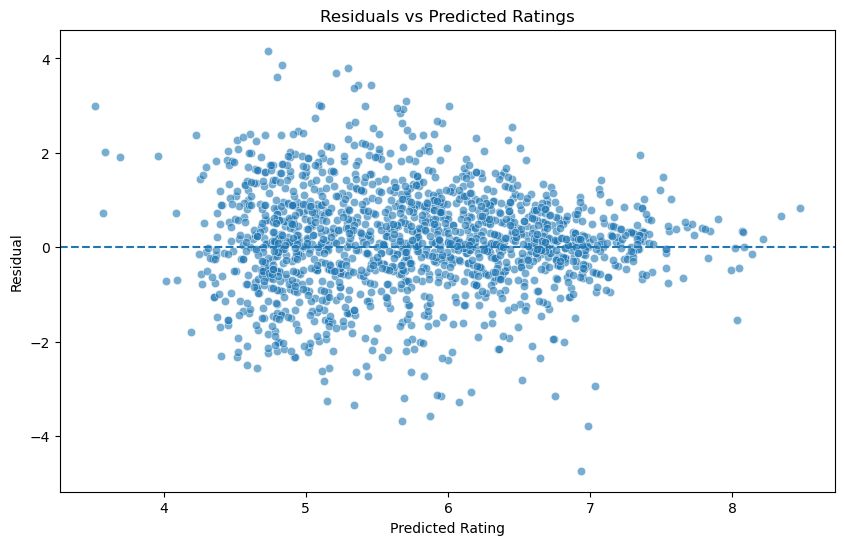

In [595]:
# SResiduals vs Predicted Ratings

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=final_prediction,
    y=residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predicted Ratings")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")

plt.show()

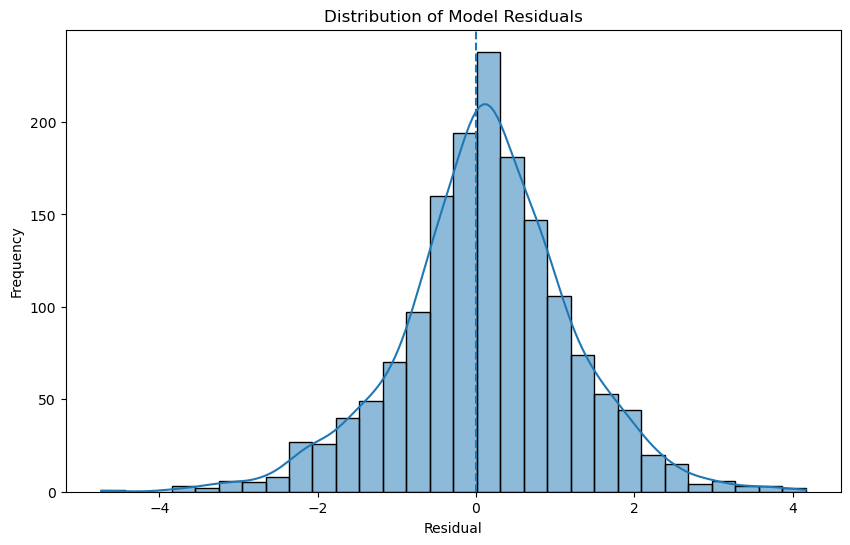

In [596]:
# Residual distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Distribution of Model Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [597]:
# Mean residual

mean_residual = np.mean(residuals)

print(
    "Mean Residual:",
    round(mean_residual, 4)
)

Mean Residual: 0.1261


In [598]:
# Identify largest residuals

diagnostic_df = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": final_prediction,
    "Residual": residuals
})

diagnostic_df["Absolute Residual"] = (
    diagnostic_df["Residual"].abs()
)

diagnostic_df = diagnostic_df.sort_values(
    by="Absolute Residual",
    ascending=False
)

diagnostic_df.head(10)

,Actual Rating,Predicted Rating,Residual,Absolute Residual
1276,2.2,6.935391,-4.735391,4.735391
278,8.9,4.736718,4.163282,4.163282
1485,8.7,4.832850,3.867150,3.867150
523,9.1,5.296441,3.803559,3.803559
798,3.2,6.987583,-3.787583,3.787583
1512,8.9,5.209626,3.690374,3.690374
806,2.0,5.673372,-3.673372,3.673372
1468,8.4,4.799438,3.600562,3.600562
1231,2.3,5.875815,-3.575815,3.575815
437,8.9,5.455601,3.444399,3.444399


In [599]:
#_29_Save the Final Model

In [600]:
# Import joblib

import joblib

print("Joblib imported successfully!")

Joblib imported successfully!


In [601]:
# Save the final trained model

model_filename = "imdb_movie_rating_model.pkl"

joblib.dump(
    tuned_model,
    model_filename
)

print("Final model saved successfully!")
print("File:", model_filename)

Final model saved successfully!
File: imdb_movie_rating_model.pkl


In [602]:
# Verify saved model

import os

if os.path.exists(model_filename):
    print("Model file exists!")
    print("File size:", round(os.path.getsize(model_filename) / 1024, 2), "KB")
else:
    print("Model file was not created.")

Model file exists!
File size: 13827.65 KB


In [603]:
# Load the saved model

loaded_model = joblib.load(model_filename)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [604]:
# Test loaded model

loaded_prediction = loaded_model.predict(X_test)

loaded_r2 = r2_score(
    y_test,
    loaded_prediction
)

print("R² Score from loaded model:", round(loaded_r2, 4))

R² Score from loaded model: 0.3584


In [605]:
# Verify saved model performance

loaded_mae = mean_absolute_error(
    y_test,
    loaded_prediction
)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_prediction
    )
)

print("Loaded Model Performance")
print("------------------------")
print("MAE :", round(loaded_mae, 4))
print("RMSE:", round(loaded_rmse, 4))
print("R²  :", round(loaded_r2, 4))

Loaded Model Performance
------------------------
MAE : 0.8227
RMSE: 1.0922
R²  : 0.3584


In [606]:
loaded_model = joblib.load(
    "imdb_movie_rating_model.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [607]:
print(X.columns.tolist())

['Year', 'Duration', 'Votes', 'MovieAge', 'Decade', 'LogVotes', 'GenreCount', 'ActorCount', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [608]:
new_data = pd.DataFrame({
    "Genre": ["Drama"],
    "Director": ["Rajkumar Hirani"],
    "Actor 1": ["Aamir Khan"],
    "Actor 2": ["Kareena Kapoor"],
    "Actor 3": ["Madhavan"],
    "Year": [2009],
    "Duration": [150],
    "Votes": [100000]
})

new_data

,Genre,Director,Actor 1,Actor 2,Actor 3,Year,Duration,Votes
0,Drama,Rajkumar Hirani,Aamir Khan,Kareena Kapoor,Madhavan,2009,150,100000


In [609]:
print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [610]:
print(loaded_model.feature_names_in_)

['Year' 'Duration' 'Votes' 'MovieAge' 'Decade' 'LogVotes' 'GenreCount'
 'ActorCount' 'Genre' 'Director' 'Actor 1' 'Actor 2' 'Actor 3']


In [611]:
print(loaded_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Duration', 'Votes',
                                                   'MovieAge', 'Decade',
                                                   'LogVotes', 'GenreCount',
                                                   'ActorCount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=2),
                                                  ['Genre', 'Director',
                                                   'Actor 1', 'Actor 2',
                                                   'Actor 3'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       min_samples_split

In [612]:
#_30_Final Results

In [613]:
# Final model results

final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R² Score"
    ],
    "Score": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

final_results

,Metric,Score
0,MAE,0.822730
1,RMSE,1.092161
2,R² Score,0.358406


In [614]:
# Final model information

print("FINAL MODEL")
print("=" * 40)

print("Model:", best_model_name)

print("\nPerformance:")
print("MAE :", round(final_mae, 4))
print("RMSE:", round(final_rmse, 4))
print("R²  :", round(final_r2, 4))

FINAL MODEL
Model: Random Forest

Performance:
MAE : 0.8227
RMSE: 1.0922
R²  : 0.3584


In [615]:
# Top 10 important features

print("TOP 10 IMPORTANT FEATURES")
print("=" * 40)

feature_importance[
    ["Feature", "Importance", "Importance_Percentage"]
].head(10)

TOP 10 IMPORTANT FEATURES


,Feature,Importance,Importance_Percentage
0,num__LogVotes,0.144630,14.463003
1,num__Votes,0.140605,14.060456
2,num__MovieAge,0.132077,13.207664
3,num__Duration,0.112893,11.289331
4,num__Year,0.112013,11.201341
5,cat__Genre_Drama,0.028466,2.846598
6,cat__Genre_Documentary,0.021927,2.192662
7,num__GenreCount,0.018530,1.852979
8,cat__Actor 2_infrequent_sklearn,0.017660,1.765992
9,cat__Director_infrequent_sklearn,0.016636,1.663612


In [616]:
# final project summary

# Project Summary

## IMDb Movie Rating Prediction

# This project focuses on predicting movie ratings using machine learning techniques.

# The dataset was explored and cleaned before performing feature engineering and preprocessing. Multiple regression algorithms were trained and compared using MAE, RMSE, and R² Score.

# The best-performing model was then optimized using hyperparameter tuning and cross-validation.

# The final model was evaluated on unseen test data using:
# - Mean Absolute Error (MAE)
# - Root Mean Squared Error (RMSE)
# - R² Score

# Feature importance analysis was also performed to understand which processed features contributed most to the model's predictions.

# Finally, the trained preprocessing and machine-learning pipeline was saved using Joblib so that it can be reused for future predictions without retraining the model.

In [617]:
# final conclusion

## Conclusion

# The project successfully developed an end-to-end machine learning system for predicting IMDb movie ratings.

# The workflow included data exploration, data cleaning, feature engineering, preprocessing, model training, model comparison, hyperparameter tuning, model evaluation, residual analysis, feature importance analysis, and model serialization.

# The final trained model can be reused to generate rating predictions for new movie information.

# The analysis also provides insights into the features that the model considers important when predicting movie ratings.

In [618]:
# project workflow diagram

## Machine Learning Workflow

# Dataset
# ↓
# Data Cleaning
# ↓
# Exploratory Data Analysis
# ↓
# Feature Engineering
# ↓
# Feature Selection
# ↓
# Data Preprocessing
# ↓
# Train/Test Split
# ↓
# Multiple Regression Models
# ↓
# Model Evaluation
# ↓
# Hyperparameter Tuning
# ↓
# Final Model Evaluation
# ↓
# Prediction Analysis
# ↓
# Feature Importance
# ↓
# Residual Analysis
# ↓
# Model Saving
# ↓
# # Movie Rating Prediction